In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

from mi_approx import *
from collisionmi import *

plt.style.use('science')

def letter_annotation(ax, xoffset, yoffset, letter, size=12, **kwargs):
    
    ax.text(xoffset, yoffset, letter, transform=ax.transAxes, size=size, weight='bold', **kwargs)

# First example BSC

In [3]:
def binary_symmetric_channel(epsilon):
    """
    X ~ Bernoulli(1/2), Y = X xor noise, noise ~ Bernoulli(epsilon).
    """
    eps = float(epsilon)
    if not (0 <= eps <= 1):
        raise ValueError("epsilon must be in [0,1].")
    return np.array(
        [
            [0.5 * (1.0 - eps), 0.5 * eps],
            [0.5 * eps, 0.5 * (1.0 - eps)],
        ]
    )

def analytic_bsc_mi(epsilon, base = np.e):
    """
    Shannon MI for the binary symmetric channel in nats:
        I = log 2 - h(epsilon)
    where h(epsilon) is binary entropy in nats.
    """
    if epsilon == 0:
        return np.log(2) / np.log(base)
    if epsilon == 1:
        return np.log(2) / np.log(base)
    if epsilon == 0.5:
        return 0.0

    h = 0.0
    if epsilon > 0:
        h -= epsilon * np.log(epsilon) / np.log(base)
    if epsilon < 1:
        h -= (1 - epsilon) * np.log(1 - epsilon) / np.log(base)

    return np.log(2) / np.log(base) - h

def simulate_population_bsc(base=np.e, r_values=(1, 2, 3, 4), n_grid=200):
    """
    Population BSC sweep.

    Uses analytic Shannon MI for the BSC and finite_resolution_MI(..., mode="population")
    for the collision-based finite-resolution approximations.
    """
    rows = []

    for eps in np.linspace(0.001, 0.499, n_grid):
        Pxy = binary_symmetric_channel(eps)

        row = {
            "model": "BSC",
            "epsilon": eps,
            "MI": analytic_bsc_mi(eps, base=base),
        }

        for r in r_values:
            row[f"I_tilde_{r}"] = finite_resolution_MI(
                Pxy,
                r=r,
                base=base,
                mode="population",
            )
            row[f"abs_error_{r}"] = abs(row[f"I_tilde_{r}"] - row["MI"])
            row[f"signed_error_{r}"] = row[f"I_tilde_{r}"] - row["MI"]

        rows.append(row)

    return pd.DataFrame(rows)

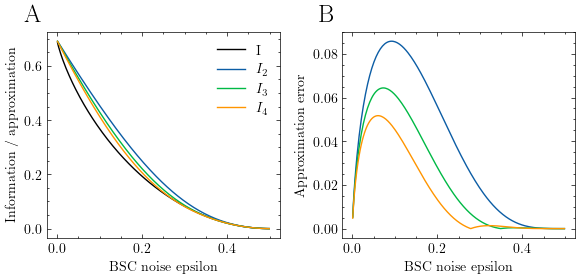

In [4]:
df_bsc = simulate_population_bsc(base=np.e)
fig, ax = plt.subplots(1,2, figsize=(6, 3))


    
lax = ax[0]
lax.plot(df_bsc["epsilon"], df_bsc["MI"], label="I", color='k')
lax.plot(df_bsc["epsilon"], df_bsc["I_tilde_2"], label="$I_2$")
lax.plot(df_bsc["epsilon"], df_bsc["I_tilde_3"], label="$I_3$")
lax.plot(df_bsc["epsilon"], df_bsc["I_tilde_4"], label="$I_4$")
lax.set_xlabel("BSC noise epsilon", size=10)
lax.set_ylabel("Information / approximation")
    
lax.legend()
letter_annotation(lax, -0.1, 1.05, 'A', size=18, color='k')
    

    
lax = ax[1]
lax.plot(df_bsc["epsilon"], df_bsc["abs_error_2"], label="$I_2$")
lax.plot(df_bsc["epsilon"], df_bsc["abs_error_3"], label="$I_3$")
lax.plot(df_bsc["epsilon"], df_bsc["abs_error_4"], label="$I_4$")
lax.set_xlabel("BSC noise epsilon")
lax.set_ylabel("Approximation error")
    
    
letter_annotation(lax, -0.1, 1.05, 'B', size=18, color='k')
    
plt.tight_layout()
fig.savefig("fig1_population_bsc_error.png", dpi=300)
    
plt.show()


# Second example BSC fixed epsilon

In [5]:
def sample_bsc(epsilon, N, rng):
    """
    Draw samples from the binary symmetric channel:
        X ~ Bernoulli(1/2), Y = X xor E, E ~ Bernoulli(epsilon).
    """
    x = rng.integers(0, 2, size=N)
    flips = rng.random(N) < epsilon
    y = np.bitwise_xor(x, flips.astype(int))
    return x, y

def run_fixed_r_bsc_simulation(
    epsilon=0.20,
    r_values=(2, 3, 4),
    Ns=(20, 30, 50, 75, 100, 150, 250, 400, 700, 1000, 1500, 2500, 4000, 7000),
    reps=1000,
    base=np.e,
    mode="u_stat",
    seed=None,
    include_nsb=False,
):
    """
    Fixed-r, increasing-N simulation for the BSC.

    Includes:
        - finite-resolution collision estimates I_tilde_r
        - plug-in MI
        - Miller--Madow MI
        - NSB MI, if nsb_mi_from_counts_joint is available
    """
    rng = np.random.default_rng(seed)
    Pxy = binary_symmetric_channel(epsilon)

    I_true = analytic_bsc_mi(epsilon, base=base)

    I_tilde = {
        r: finite_resolution_MI(Pxy, r=r, base=base, mode="population")
        for r in r_values
    }

    rows = []

    for N in Ns:
        collision_estimates = {r: [] for r in r_values}
        plugin_estimates = []
        mm_estimates = []
        nsb_estimates = []

        for _ in range(reps):
            x, y = sample_bsc(epsilon, N, rng)
            counts_xy = joint_counts_from_samples(x, y, m=2)

            plugin_estimates.append(plugin_mi_from_counts(counts_xy, base=base))
            mm_estimates.append(miller_madow_mi_from_counts(counts_xy, base=base))

            if include_nsb:
                try:
                    nsb_est = nsb_mi_from_counts_joint(counts_xy, base=base)
                    if np.isfinite(nsb_est):
                        nsb_estimates.append(nsb_est)
                except Exception:
                    pass

            for r in r_values:
                est = finite_resolution_MI(
                    counts_xy,
                    r=r,
                    base=base,
                    mode=mode,
                )
                if np.isfinite(est):
                    collision_estimates[r].append(est)

        def summarize_estimates(estimates, label, target):
            estimates = np.asarray(estimates, dtype=float)
            estimates = estimates[np.isfinite(estimates)]

            if len(estimates) == 0:
                return {
                    "epsilon": epsilon,
                    "r": label,
                    "N": N,
                    "mode": label,
                    "mean": np.nan,
                    "sd": np.nan,
                    "se": np.nan,
                    "I_true": I_true,
                    "I_tilde": target,
                    "deterministic_gap": target - I_true,
                    "bias_vs_shannon": np.nan,
                    "bias_vs_finite_target": np.nan,
                    "mse_vs_shannon": np.nan,
                    "mse_vs_finite_target": np.nan,
                    "n_success": 0,
                }

            mean_est = estimates.mean()
            sd_est = estimates.std(ddof=1) if len(estimates) > 1 else 0.0
            se_est = sd_est / np.sqrt(len(estimates)) if len(estimates) > 1 else 0.0

            return {
                "epsilon": epsilon,
                "r": label,
                "N": N,
                "mode": label,
                "mean": mean_est,
                "sd": sd_est,
                "se": se_est,
                "I_true": I_true,
                "I_tilde": target,
                "deterministic_gap": target - I_true,
                "bias_vs_shannon": mean_est - I_true,
                "bias_vs_finite_target": mean_est - target,
                "mse_vs_shannon": np.mean((estimates - I_true) ** 2),
                "mse_vs_finite_target": np.mean((estimates - target) ** 2),
                "n_success": len(estimates),
            }

        rows.append(summarize_estimates(plugin_estimates, "plugin", I_true))
        rows.append(summarize_estimates(mm_estimates, "miller_madow", I_true))

        if include_nsb:
            rows.append(summarize_estimates(nsb_estimates, "nsb", I_true))

        for r in r_values:
            rows.append(
                summarize_estimates(
                    collision_estimates[r],
                    r,
                    I_tilde[r],
                )
            )

    return pd.DataFrame(rows)

In [6]:
epsilon = 0.20
r_values = [2, 3, 4, 5]
Ns = np.array([10, 15, 20, 30, 50, 75, 100, 150, 250, 500])

df_fixed_all = run_fixed_r_bsc_simulation(
    epsilon=epsilon,
    r_values=r_values,
    Ns=Ns,
    reps=1000,
    base=np.e,
    mode="u_stat",
    seed=7,
    include_nsb = False
)

I_true = df_fixed_all["I_true"].dropna().iloc[0]



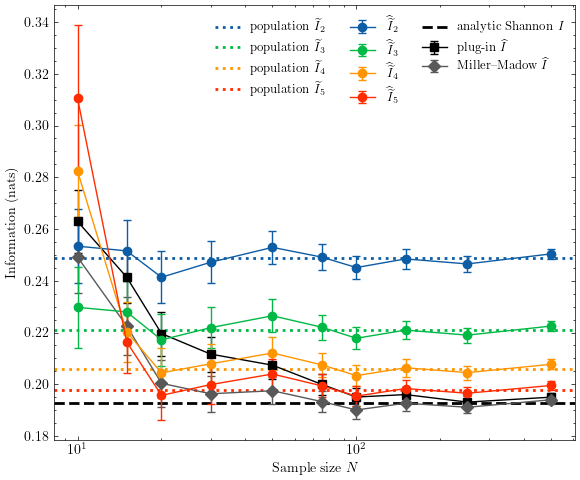

In [7]:




fig, ax = plt.subplots(figsize=(6, 5))



# Standard Shannon MI estimators.
estimator_styles = {
    "plugin": {
        "label": r"plug-in $\widehat I$",
        "marker": "s",
        "linestyle": "-",
        "color": "black",
    },
    "miller_madow": {
        "label": r"Miller--Madow $\widehat I$",
        "marker": "D",
        "linestyle": "-",
        "color": "0.35",
    },
    "nsb": {
        "label": r"NSB $\widehat I$",
        "marker": "^",
        "linestyle": "-",
        "color": "0.6",
    },
}

ax.axhline(
    I_true,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"analytic Shannon $I$"
)

for estimator, style in estimator_styles.items():
    df_e = df_fixed_all[df_fixed_all["r"] == estimator].sort_values("N")
    if len(df_e) == 0 or df_e["mean"].isna().all():
        continue

    ax.errorbar(
        df_e["N"],
        df_e["mean"],
        yerr=2 * df_e["se"],
        marker=style["marker"],
        capsize=3,
        linestyle=style["linestyle"],
        color=style["color"],
        label=style["label"],
    )

# Collision estimators and population targets.
for r in r_values:
    df_r = df_fixed_all[df_fixed_all["r"] == r].sort_values("N")

    line = ax.errorbar(
        df_r["N"],
        df_r["mean"],
        yerr=2 * df_r["se"],
        marker="o",
        capsize=3,
        linestyle="-",
        label=rf"$\widehat{{\widetilde I}}_{r}$"
    )

    color = line.lines[0].get_color()

    ax.axhline(
        df_r["I_tilde"].iloc[0],
        color=color,
        linestyle=":",
        linewidth=2,
        label=rf"population $\widetilde I_{r}$"
    )
#ax.set_ylim(None, 0.28)
ax.set_xscale("log")
ax.set_xlabel("Sample size $N$")
ax.set_ylabel("Information (nats)")
#ax.set_title(rf"Fixed-order collision estimates and Shannon MI estimators for BSC($\epsilon={epsilon}$)")


handles, labels = ax.get_legend_handles_labels()
#ax.legend(ncol=3, fontsize=9)
order = [1,2,3,4,7,8,9,10,0,5,6]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], ncols=3, fontsize=9)
plt.tight_layout()
fig.savefig( "fig2_sample_bsc_error.png", dpi=300)
plt.show()

# Third Example of collision weight


In [8]:
def make_plateau_distributions():
    """
    Distributions designed to show gradual concentration with collision order.
    Each has many states with comparable probabilities, so p_i^k does not
    collapse immediately to the maximum.
    """
    # 100-state uniform
    uniform = np.ones(100)
    uniform = uniform / uniform.sum()

    # Mild three-tier distribution: broad support, weak concentration
    mild = np.r_[
        np.full(20, 3.0),
        np.full(30, 2.0),
        np.full(50, 1.0),
    ]
    mild = mild / mild.sum()

    # Moderate three-tier distribution
    moderate = np.r_[
        np.full(10, 5.0),
        np.full(30, 2.0),
        np.full(60, 1.0),
    ]
    moderate = moderate / moderate.sum()

    # Stronger tiered distribution, but not one single dominant state
    strong = np.r_[
        np.full(5, 8.0),
        np.full(20, 2.0),
        np.full(75, 1.0),
    ]
    strong = strong / strong.sum()

    return {
        "Uniform": uniform,
        "Mild tiers": mild,
        "Moderate tiers": moderate,
        "Strong tiers": strong,
    }


def collision_weight_summary(distributions, k_values):
    rows = []

    for name, p in distributions.items():
        p = np.asarray(p, dtype=float)
        p = p / p.sum()
        p_sorted = np.sort(p)[::-1]

        for k in k_values:
            raw = p_sorted ** k
            w = raw / raw.sum()

            eff_support = 1.0 / np.sum(w ** 2)
            cumulative = np.cumsum(w)

            rows.append({
                "distribution": name,
                "k": k,
                "top1_share": w[0],
                "top5_share": w[:5].sum(),
                "top10_share": w[:10].sum(),
                "effective_support": eff_support,
                "n50": np.searchsorted(cumulative, 0.50) + 1,
                "n90": np.searchsorted(cumulative, 0.90) + 1,
                "n99": np.searchsorted(cumulative, 0.99) + 1,
            })

    return pd.DataFrame(rows)


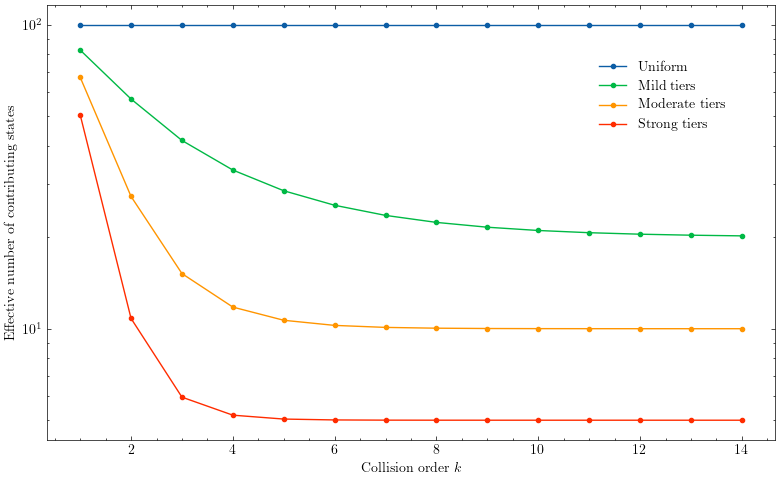

In [9]:
distributions = make_plateau_distributions()
k_values = np.arange(1, 15)
df_weights = collision_weight_summary(distributions, k_values)


# Plot effective support
fig, ax = plt.subplots(figsize=(8, 5))

for name in distributions:
    df = df_weights[df_weights["distribution"] == name]
    ax.plot(df["k"], df["effective_support"], marker="o", markersize=3, label=name)

ax.set_xlabel("Collision order $k$")
ax.set_ylabel("Effective number of contributing states")
#ax.set_title("Collision order reduces the effective support")
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(0.95, 0.9))
plt.tight_layout()
plt.savefig("fig3_collision_order.png", dpi=300)
plt.show()

